In [1]:
#importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Se definen parámetros 

#Probabilidad del bits
p0 = 0.5
p1 = 1-p0

#Número de bits de la secuencia a generar
N=300

#Parámetros de modulación M-ASK
formato='polar' 
M=16
n = int(np.log2(M))
Ts = 0.001
fs=1/Ts
# parámetros

#parámetros para la gráfica de señales
fmuestreo = 100000
fc = 10000
Ac=1



In [3]:
def generador_secuencia(n, p0, p1, semilla=None):
    # validación
    if not np.isclose(p0 + p1, 1):
        raise ValueError("Las probabilidades deben cumplir: p0 + p1 = 1")
    rng = np.random.default_rng(semilla)
    return rng.choice([0, 1], size=n, p=[p0, p1])

# ejemplo
secuencia = generador_secuencia(N, p0, p1, semilla=42)
print(secuencia)

[1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0
 0 0 0 1 1 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 0 0 1 0
 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 1
 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1 1 1 1 1 1 0 1
 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 0 1 1 1 0 0 1 0 0 0
 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 1 1
 1 1 1 1]


In [4]:
#Convertidor de datos


def gray_code(n):
    """Genera códigos Gray de n bits"""
    if n == 0:
        return ['']
    prev = gray_code(n-1)
    return ['0' + code for code in prev] + ['1' + code for code in reversed(prev)]


def convertidor_datos(bits, M=4, formato='polar'):
    n = int(np.log2(M))
    
    # asegurar múltiplo de n
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    # agrupar bits
    grupos = bits.reshape(-1, n)
    
    # generar código Gray
    gray = gray_code(n)
    
    # mapping: binario -> índice Gray
    mapping = {tuple(int(b) for b in gray[i]): i for i in range(M)}
    
    # convertir grupos a índices
    indices = [mapping[tuple(grupo)] for grupo in grupos]
    indices = np.array(indices)
    
    # niveles M-ASK
    if formato == 'polar':
        # niveles simétricos
        niveles = 2*indices - (M - 1)
    elif formato == 'unipolar':
        niveles = indices

    else:
        raise ValueError("Formato debe ser 'polar' o 'unipolar'")
    
    return niveles


Ik = convertidor_datos(secuencia, M, formato)
print(Ik)
    

[ 11  -5 -13   1  11  11  15  -5 -15 -13  -7   1  15   5  -1  11   7 -15
  15  -5   9  -9  -3 -13 -13   3   1  -1  -3   3   1 -15  -3   9   9 -11
 -13 -11  -3  -5  -1  11  -3  -1  -5   7   1   9  -1   1   7 -13  -5  -5
  -9 -11  -3  15   5  -1   3   7 -11 -13  13  -1  15 -15  -7  -5 -15  15
   9  11   5]


In [5]:
def pulso_rectangular(t, Ts, fmuestreo):
    eps = 1/(2*fmuestreo)
    return np.where((t >= -eps) & (t < Ts - eps), 1.0, 0.0)

def xi(simbolos, Ts, fmuestreo):
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos) * Ns) / fmuestreo
    s = np.zeros_like(t, dtype=float)
    
    for k, a_k in enumerate(simbolos):
        s += a_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    return t, s
# señal banda base
t, s = xi(Ik[:20], Ts, fmuestreo)
# portadora
portadora = np.cos(2 * np.pi * fc * t)

# señal modulada
x = s * portadora




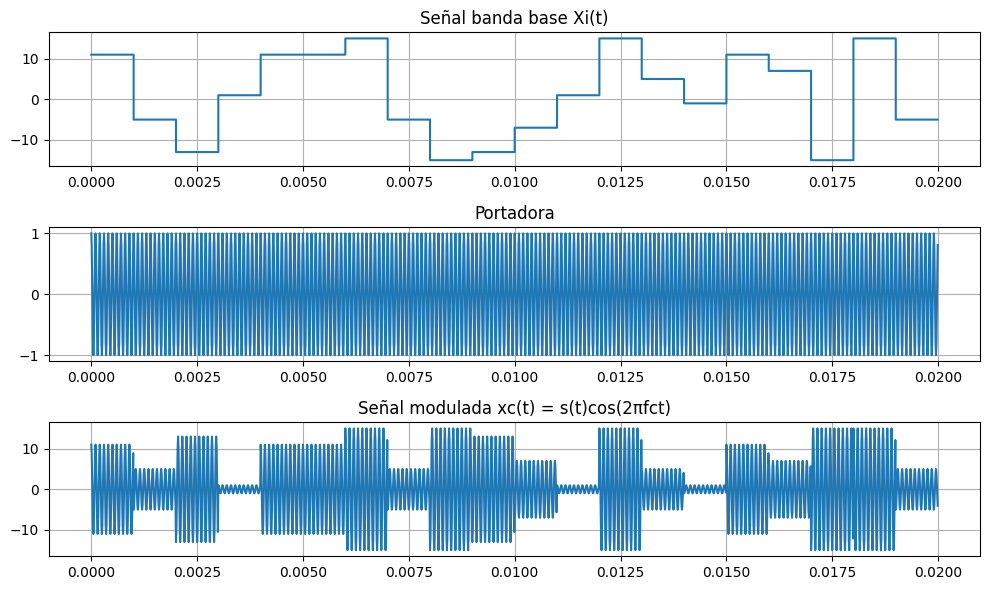

In [6]:
# gráficos
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.step(t, s, where='post')
plt.title("Señal banda base Xi(t)")
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, portadora)
plt.title("Portadora")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, x)
plt.title("Señal modulada xc(t) = s(t)cos(2πfct)")
plt.grid()

plt.tight_layout()
plt.show()

# Variables estadísticas para el cálculo de la DEP

In [7]:

#Tabla de correspondencia
tabla={}
if formato == 'polar':
    tabla = dict(zip(gray_code(n),[2*i - (M-1) for i in range(M)] ))
else: 
    tabla = dict(zip(gray_code(n), [i for i in range(M)]))
    
for bits,simbolos in tabla.items():
    print(bits, simbolos)



0000 -15
0001 -13
0011 -11
0010 -9
0110 -7
0111 -5
0101 -3
0100 -1
1100 1
1101 3
1111 5
1110 7
1010 9
1011 11
1001 13
1000 15


In [8]:
#se obtiene la probabilidad de los símbolos
def get_prob_simbolo(bits, p0, p1):
    prob = 1
    for b in bits:
        if b == '0':
            prob *= p0
        else:
            prob *= p1
    return prob
P_ak = {tabla[bits]: get_prob_simbolo(bits, p0, p1) for bits in tabla}
#Imprime valor de probabilidad asociado a cada simbolo
print("simb.\tprobs")
for simbolo,probabilidad in P_ak.items():
    print(f"{simbolo}\t{probabilidad}")

simb.	probs
-15	0.0625
-13	0.0625
-11	0.0625
-9	0.0625
-7	0.0625
-5	0.0625
-3	0.0625
-1	0.0625
1	0.0625
3	0.0625
5	0.0625
7	0.0625
9	0.0625
11	0.0625
13	0.0625
15	0.0625


# Media de ak
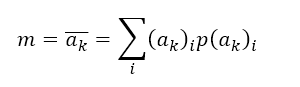

In [9]:
#Determinar la media
def get_media(data): 
    media=0
    for i,v in data.items(): 
        media+=i*v
    return media
m=get_media(P_ak)

print(f'media = {m} ')      
        

media = 0.0 


# Varianza de ak
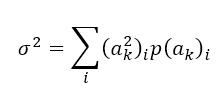

In [10]:
#Determinar valor cuadratico medio
def get_rms(data): 
    rms=0
    for i,v in data.items(): 
        rms+=i*i*v
    return rms
    
#determinar varianza
var=get_rms(P_ak)-m*m

print(f'varianza = {var} ')   


varianza = 85.0 


# Densidad Espectral de Potencia (DEP) M-ASK
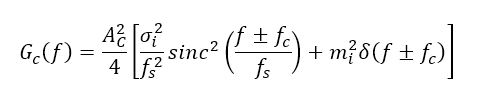

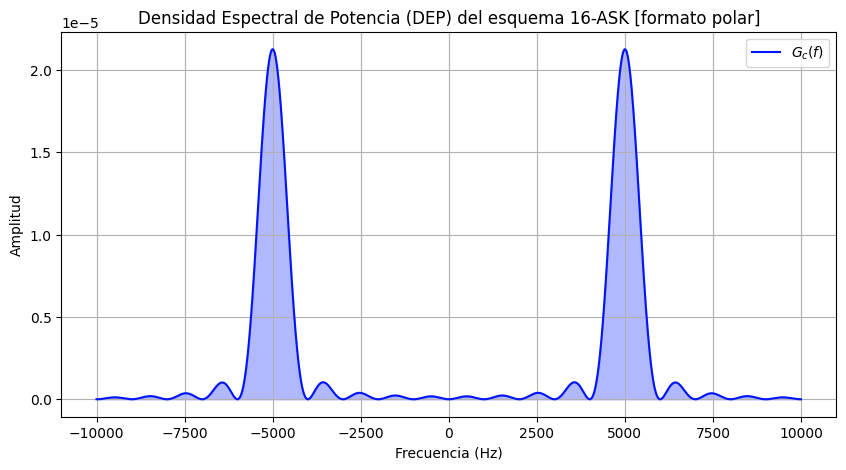

In [11]:
# Vector de frecuencias

fs=1000
fc=5000

f = np.linspace(-10000 ,10000, 200000)

def delta(arg):
    delta_singnal = np.zeros_like(f)
    idx= np.argmin(np.abs(arg))
    delta_singnal[idx] = 1
    return delta_singnal

p_continua=(var/fs**2)*(np.sinc((f + fc)/fs)**2+np.sinc((f - fc)/fs)**2)

Atenuador=0.000001*(m**2) #se atenua con la finalidad de poder observar la parte continua
p_discreta=Atenuador*(delta(f+fc)+delta(f-fc))

Gc_t= (Ac**2/4)*(p_continua+p_discreta)

plt.figure(figsize=(10,5))
plt.plot(f, Gc_t,color='#0015FA', label=r'$G_c(f)$')
plt.fill_between(f, Gc_t,color='#0015FA', alpha=0.3)
titulo =f"Densidad Espectral de Potencia (DEP) del esquema {M}-ASK [formato {formato}]"
plt.title(titulo)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.show()





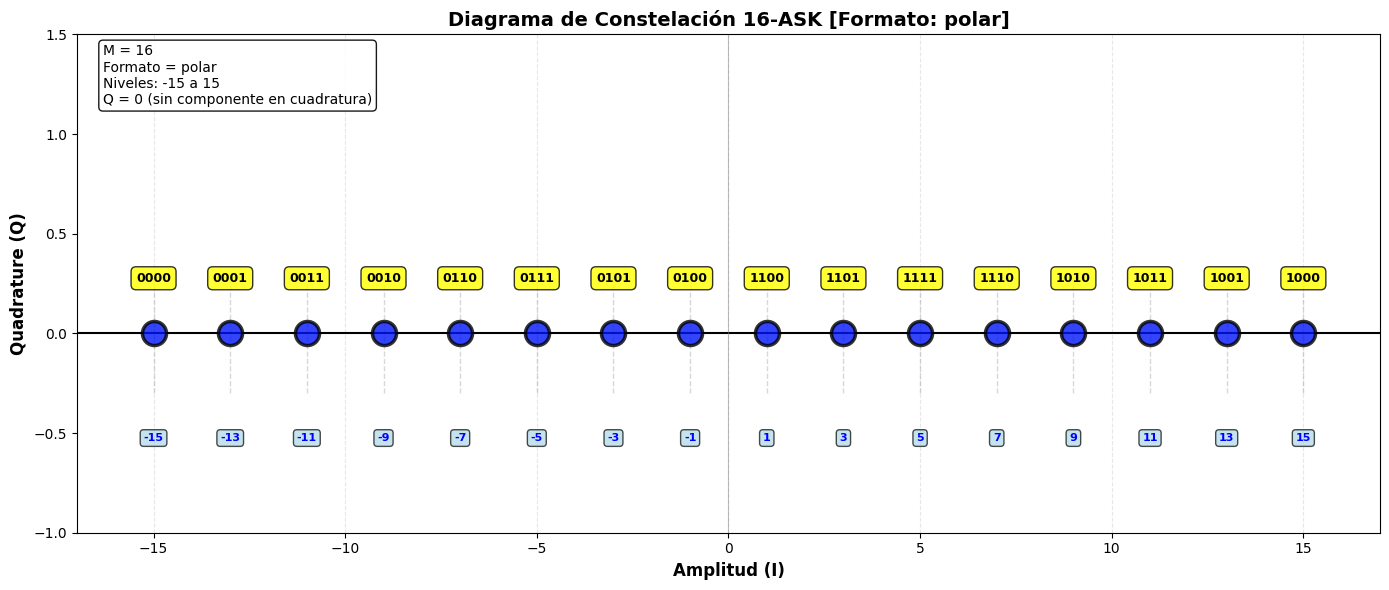

Diagrama de constelación 16-ASK generado
Número de puntos de señal: 16

Niveles de amplitud y códigos Gray:
  0000: -15
  0001: -13
  0011: -11
  0010: -9
  0110: -7
  0111: -5
  0101: -3
  0100: -1
  1100: 1
  1101: 3
  1111: 5
  1110: 7
  1010: 9
  1011: 11
  1001: 13
  1000: 15


In [12]:
# Generar todos los puntos de la constelación M-ASK
# Obtener códigos Gray y niveles
gray_codes = gray_code(n)
constelacion_niveles = []
labels_constelacion = []

for code in gray_codes:
    nivel = tabla[code]
    constelacion_niveles.append(nivel)
    labels_constelacion.append(code)

# Crear diagrama de constelación
fig, ax = plt.subplots(figsize=(14, 6))

# Dibujar puntos de la constelación en el eje I (eje horizontal)
# En M-ASK, Q=0 (no hay componente en cuadratura)
Q_values = [0] * len(constelacion_niveles)

# Dibujar puntos
ax.scatter(constelacion_niveles, Q_values, s=300, c='#0015FA', marker='o', 
           edgecolors='black', linewidths=2.5, zorder=3, alpha=0.8)

# Agregar líneas verticales desde cada punto
for nivel in constelacion_niveles:
    ax.plot([nivel, nivel], [-0.3, 0.3], 'gray', linestyle='--', linewidth=1, alpha=0.3, zorder=1)

# Agregar etiquetas de códigos Gray
for nivel, label in zip(constelacion_niveles, labels_constelacion):
    # Etiqueta arriba del punto
    ax.annotate(label, (nivel, 0), xytext=(0, 35), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8))
    
    # Valor del nivel debajo del punto
    ax.text(nivel, -0.5, f'{nivel}', ha='center', va='top',
            fontsize=8, color='blue', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

# Configuración de ejes
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3, linestyle='--', axis='x')
ax.set_xlabel('Amplitud (I)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quadrature (Q)', fontsize=12, fontweight='bold')
ax.set_title(f'Diagrama de Constelación {M}-ASK [Formato: {formato}]', fontsize=14, fontweight='bold')

# Ajustar límites
if formato == 'polar':
    margin = 2
    ax.set_xlim([min(constelacion_niveles) - margin, max(constelacion_niveles) + margin])
else:
    ax.set_xlim([-2, max(constelacion_niveles) + 2])
ax.set_ylim([-1, 1.5])

# Agregar información adicional
if formato == 'polar':
    niveles_info = f"Niveles: {min(constelacion_niveles)} a {max(constelacion_niveles)}"
else:
    niveles_info = f"Niveles: 0 a {max(constelacion_niveles)}"

info_text = f'M = {M}\nFormato = {formato}\n{niveles_info}\nQ = 0 (sin componente en cuadratura)'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

plt.tight_layout()
plt.show()

print(f"Diagrama de constelación {M}-ASK generado")
print(f"Número de puntos de señal: {len(constelacion_niveles)}")
print(f"\nNiveles de amplitud y códigos Gray:")
for code, nivel in zip(labels_constelacion, constelacion_niveles):
    print(f"  {code}: {nivel}")

# Diagrama de Constelación M-ASK